Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report

Load Dataset

In [ ]:
df = pd.read_csv("/content/Heart_Disease_Prediction.csv")

df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [ ]:
print(df.shape)
print(df.info())
print(df.describe())

(270, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), i

Missing Values Check

In [ ]:
print(df.isnull().sum())

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64


Exploratory Data Analysis (EDA)

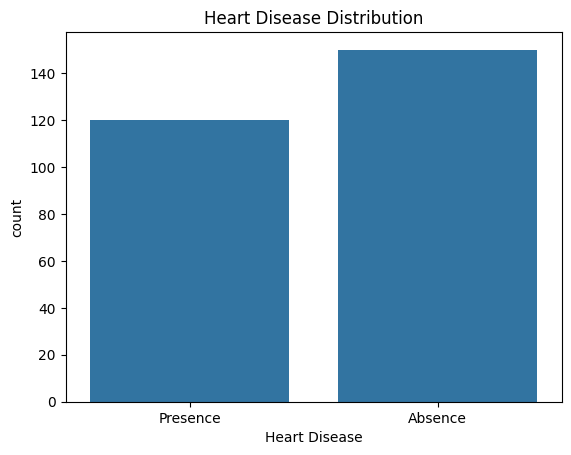

In [ ]:
sns.countplot(x='Heart Disease', data=df)

plt.title("Heart Disease Distribution")

plt.show()

Features and Labels

In [ ]:
X = df.drop("Heart Disease", axis=1)

y = df["Heart Disease"]

Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Train Model

In [ ]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

Prediction

In [ ]:
y_pred = model.predict(X_test)

Accuracy

In [ ]:
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

Accuracy: 0.9074074074074074


Confusion Matrix

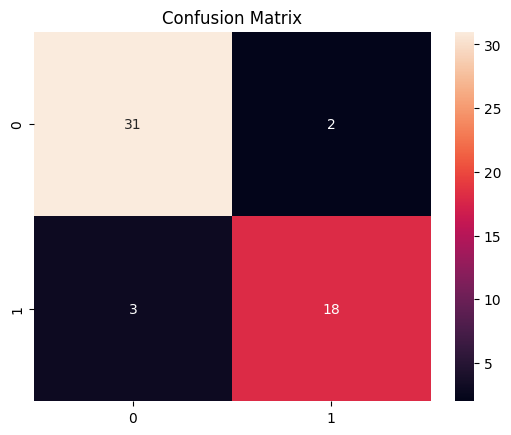

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

ROC Curve

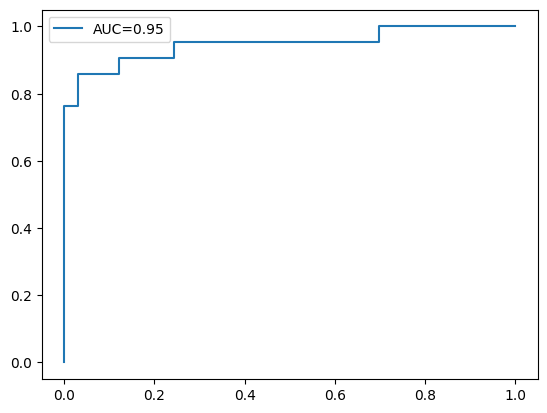

In [ ]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob,
    pos_label='Presence'
)

roc_auc = auc(
    fpr,
    tpr
)

plt.plot(
    fpr,
    tpr,
    label="AUC="+str(round(roc_auc,2))
)

plt.legend()

plt.show()

Important Features

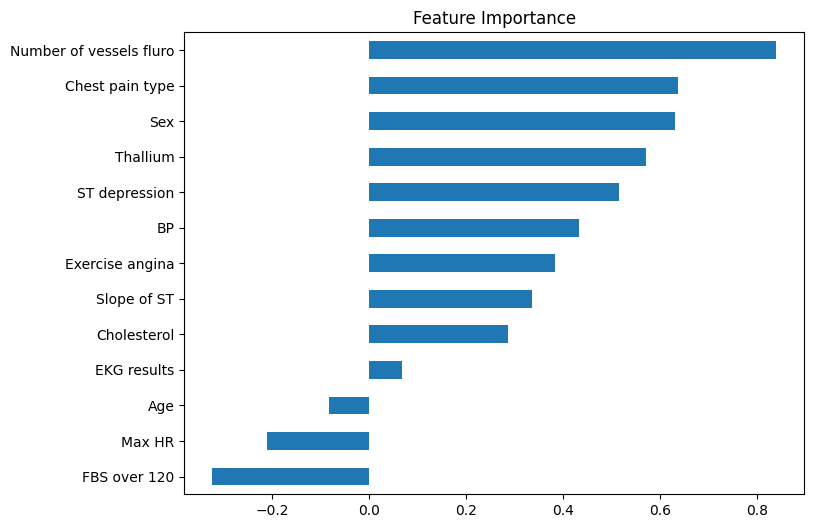

In [ ]:
importance = pd.Series(
    model.coef_[0],
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Feature Importance")

plt.show()

Final Insights

In [ ]:
print("""
Insights:

1. Logistic Regression successfully classified patients.
2. ROC curve shows classification performance.
3. Important features strongly affect prediction.
""")


Insights:

1. Logistic Regression successfully classified patients.
2. ROC curve shows classification performance.
3. Important features strongly affect prediction.

